In [28]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Quantum Computing Libraries
import pennylane as qml

# Classical Machine Learning & Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### Load Data

In [2]:
def get_raw_data(device, max_per_class):
    # Mapping to correct dataset abbreviations
    devices = {
        "EPOC": ["dataset/EP1.01.txt", "EP", 128, 14],
        "MW": ["dataset/MW.txt", "MW", 512, 1], 
        "MU": ["dataset/MU.txt", "MU", 220, 4], 
        "IN": ["dataset/IN.txt", "IN", 128, 5]
    }

    filename, device_keyword, fs, n_c = devices[device]
    
    # Structure: { event_id: { 'code': label, 'channels': [array1, array2, ...] } }
    event_groups = {}
    
    with open(filename, 'r') as file:
        for line in file:
            parts = line.split('\t')
            if len(parts) < 7:
                continue
                
            event_id = int(parts[1])
            code = int(parts[4])
            
            # --- QML FILTER: Only keep digits 0 up to 4 ---
            if code not in [0, 1, 2, 3, 4]:
                continue
                
            # Clean trailing artifacts from the data string
            data_str = parts[6].strip().replace('â€¦', '').replace('…', '')
            channel_data = np.array([float(val) for val in data_str.split(',') if val])
            
            if event_id not in event_groups:
                event_groups[event_id] = {'code': code, 'channels': []}
                
            event_groups[event_id]['channels'].append(channel_data)

    # Balanced collection for 5 classes
    X_raw = []
    y_raw = []
    counter = {0: 0, 1: 0, 2: 0, 3: 0, 4: 0}

    for event_id, info in event_groups.items():
        label = info['code']
        
        # Ensure the trial has collected ALL expected channels
        if len(info['channels']) == n_c:
            if counter[label] < max_per_class:
                X_raw.append(info['channels'])
                y_raw.append(label)
                counter[label] += 1

    return X_raw, np.array(y_raw), fs, n_c



X, y, fs, n_c = get_raw_data(device="EPOC", max_per_class = 6351)


### Filter Data

In [3]:
# Notch: w0=50, Q=30
notch_b, notch_a = signal.iirnotch(w0=50, Q=30, fs=fs)
# Bandpass: N=6, Wn=[0.5, 63]
bp_b, bp_a = signal.butter(N=6, Wn=[0.5, 63], btype='bandpass', fs=fs)

X_filtered = []
y_filtered = []

# Target window size (2 seconds * fs = 256 points)
target_len = 2*fs  

# Loop through every individual trial and its label simultaneously
for trial, label in zip(X, y):
    filtered_channels = []
    is_valid_trial = True
    
    # Check if all channels meet the minimum length requirements
    for channel_data in trial:
        if len(channel_data) < target_len:
            is_valid_trial = False
            break
            
    if not is_valid_trial:
        continue # Drop trials that don't have enough data points to slice
        
    for channel_data in trial:
        # Apply filters sequentially
        filt_notch = signal.lfilter(notch_b, notch_a, channel_data)
        filt_band = signal.lfilter(bp_b, bp_a, filt_notch)
        
        # Trim the first 32 samples (startup artifacts) up to 256 points
        # Yields exactly 224 data points per channel
        trimmed_channel = filt_band[32:target_len]
        filtered_channels.append(trimmed_channel)
        
    X_filtered.append(filtered_channels)
    y_filtered.append(label)

# Convert to precise arrays (Will pass with no errors now!)
X_matrix = np.array(X_filtered, dtype=np.float64)
print(X_matrix.shape)
y = np.array(y_filtered)

(31577, 14, 224)


### Extract Features of the signal

In [42]:
def extract_features_fast(X_matrix, fs):
    """
    Extracts 3 Time-Domain and 5 Frequency-Domain features directly 
    across the entire continuous trial length.
    """
    total_samples_features = []
    
    for sample_idx in range(X_matrix.shape[0]):
        trial_data = X_matrix[sample_idx] # Shape: (14, time_points)
        trial_features = []
        
        for ch in range(14):
            channel_signal = trial_data[ch, :]
            
            # 1. Time Domain Features
            var_feat = np.var(channel_signal)
            ptp_feat = np.ptp(channel_signal)
            rms_feat = np.sqrt(np.mean(channel_signal**2))
            trial_features.extend([var_feat, ptp_feat, rms_feat])
            
            # 2. Frequency Domain Features
            # Using standard nperseg defaults for full-length signal stability
            nperseg = min(len(channel_signal), 64) 
            if nperseg < 8:
                trial_features.extend([0.0, 0.0, 0.0, 0.0, 0.0])
                continue
                
            freqs, psd = welch(channel_signal, fs=fs, nperseg=nperseg)
            
            # Safe band extraction using optimized index slicing
            def get_band_power(f_min, f_max, freqs, psd):
                indices = np.where((freqs >= f_min) & (freqs <= f_max))[0]
                if len(indices) > 0:
                    return float(np.mean(psd[indices]))
                return 0.0

            delta = get_band_power(0.5, 4, freqs, psd)
            theta = get_band_power(4, 8, freqs, psd)
            alpha = get_band_power(8, 12, freqs, psd)
            beta  = get_band_power(12, 30, freqs, psd)
            gamma = get_band_power(30, 63, freqs, psd)
            
            trial_features.extend([delta, theta, alpha, beta, gamma])
            
        total_samples_features.append(trial_features)
        
    return np.array(total_samples_features)

print("Feature Extraction...")
X_features = extract_features_fast(X_matrix, fs)
print(f" Extraction complete! Final structural shape: {X_features.shape}")

Feature Extraction...
 Extraction complete! Final structural shape: (31577, 112)


### Train Test Split and Feature Scaling

In [47]:
# 2. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Scaling for Angle Encoding
scaler = Normalizer(norm='l2')
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"New Feature Matrix Shape of Training Data (Samples, Features): {X_train_scaled.shape}")
print(f"New Feature Matrix Shape of Test Data (Samples, Features): {X_test_scaled.shape}")

New Feature Matrix Shape of Training Data (Samples, Features): (22103, 112)
New Feature Matrix Shape of Test Data (Samples, Features): (9474, 112)


### Create a Quantum Reservoir Framework

In [44]:
# 1. Allocate 1 Qubit per feature (8 qubits for your 8 PCA components)
num_qubits = 8  
dev = qml.device("default.qubit", wires=num_qubits)

# Establish fixed random reservoir weights (Never optimized via gradients!)
np.random.seed(42)
reservoir_depth = 3  # Depth determines how heavily the data is mixed. 3 is a great standard.

# Structure the shape to handle multiple layers: (depth layers, 8 qubits)
# Initialized to [-pi, pi] to give qubits full exploration of the Bloch sphere
W_random = np.random.uniform(-np.pi, np.pi, size=(reservoir_depth, num_qubits))

@qml.qnode(dev)
def qelm_circuit(inputs):
    """
    Class 11 Quantum Reservoir Structure (Option 1: Cyclic Entanglement)
    Maps normalized inputs into an entangling multi-qubit Pauli expectation state.
    """
    # Task 1: Linear Angle Encoding Layer
    qml.AmplitudeEmbedding(features=inputs, wires=range(num_qubits), normalize=True, pad_with=0.0)
        
    # Task 2: Untrained Cyclic Multi-Layer Reservoir Mixer
    # This loops entanglement back to the start and repeats across multiple layers
    for layer in range(reservoir_depth):
        
        # A. Cyclic Entanglement Loop: Connects neighboring qubits, 
        # and loops the last qubit (7) back to the first qubit (0)
        for i in range(num_qubits):
            qml.CNOT(wires=[i, (i + 1) % num_qubits])
        
        # B. Fixed Rotation Phase Shift: Alters the state based on our layer weights
        for i in range(num_qubits):
            qml.RZ(W_random[layer, i], wires=i)
            
    # Task 3: Extract single-qubit Pauli Z expectation value features
    return [qml.expval(qml.PauliZ(i)) for i in range(num_qubits)]

# Print a quick conformation that the architecture is set up
print("✅ Upgraded Quantum Reservoir initialized successfully.")
print(f"Total Qubits: {num_qubits} | Reservoir Depth Layers: {reservoir_depth}")

✅ Upgraded Quantum Reservoir initialized successfully.
Total Qubits: 8 | Reservoir Depth Layers: 3


In [48]:
# Use the function name defined above and pass the params
print("1/2: Projecting training features into Pauli space...")
X_train_quantum = np.array([qelm_circuit(x) for x in X_train_scaled])

print("2/2: Projecting testing features into Pauli space...")
X_test_quantum = np.array([qelm_circuit(x) for x in X_test_scaled])

print(f"\n Quantum Transformation Complete!")

1/2: Projecting training features into Pauli space...
2/2: Projecting testing features into Pauli space...

 Quantum Transformation Complete!


### Training and Verification of Model

In [52]:
# Alpha=1.0 introduces L2 regularization to stabilize the classical hyperplane
clf = RidgeClassifier(
    alpha=1.0, 
    class_weight='balanced', 
    random_state=42
)

clf.fit(X_train_quantum, y_train)
# Predict
y_train_pred = clf.predict(X_train_quantum)
y_test_pred = clf.predict(X_test_quantum)

# =====================================================================
# STEP 5: THE COMPLETE EVALUATION DASHBOARD
# =====================================================================
print("\n==================== TESTING SET METRICS ====================")
print(f"Quantum QELM Test Accuracy  : {accuracy_score(y_test, y_test_pred) * 100:.2f}%")
print("=================================================================")
print(classification_report(y_test, y_test_pred, target_names=['Thinking Digit 0', 'Thinking Digit 1', 'Thinking Digit 2', 'Thinking Digit 3', 'Thinking Digit 4']))


==================== TESTING SET METRICS ====================
Quantum QELM Test Accuracy  : 20.15%
                  precision    recall  f1-score   support

Thinking Digit 0       0.20      0.31      0.24      1896
Thinking Digit 1       0.21      0.15      0.17      1898
Thinking Digit 2       0.18      0.06      0.09      1892
Thinking Digit 3       0.20      0.32      0.25      1895
Thinking Digit 4       0.21      0.17      0.18      1893

        accuracy                           0.20      9474
       macro avg       0.20      0.20      0.19      9474
    weighted avg       0.20      0.20      0.19      9474



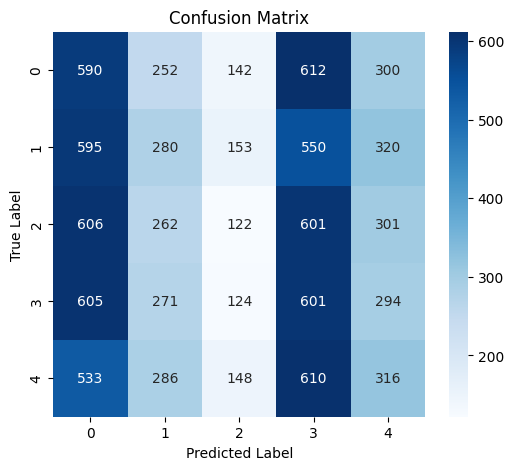

In [53]:
# 1. Compute the matrix
cm = confusion_matrix(y_test, y_test_pred)

# 2. Plotting
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['0', '1', '2', '3', '4'], 
            yticklabels=['0', '1', '2', '3', '4'])

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()